In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tabulate import tabulate

In [2]:
diabetes = load_diabetes()
df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [3]:
X,y = diabetes.data, diabetes.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
lin_reg=LinearRegression()
lin_reg.fit(X_train,y_train)
y_pred_lin = lin_reg.predict(X_test)
mse_lin = mean_squared_error(y_test,y_pred_lin)
lasso=Lasso(alpha=0.1)
lasso.fit(X_train,y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test,y_pred_lasso)

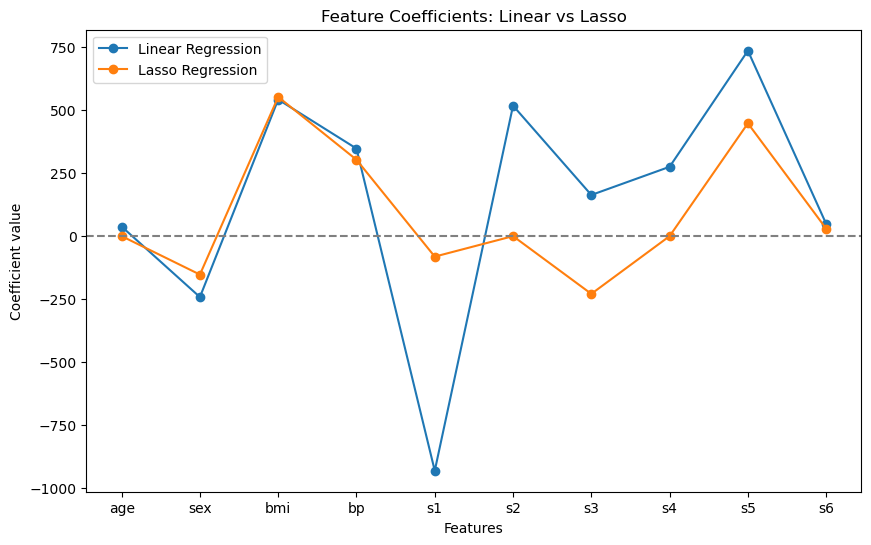

In [4]:
plt.figure(figsize=(10,6))
plt.plot(diabetes.feature_names,lin_reg.coef_,'o-',label="Linear Regression")
plt.plot(diabetes.feature_names,lasso.coef_,'o-',label="Lasso Regression")
plt.axhline(0,color='gray',linestyle='--')
plt.title("Feature Coefficients: Linear vs Lasso")
plt.xlabel("Features")
plt.ylabel("Coefficient value")
plt.legend()
plt.show()